In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor, as_completed


from shapely import points, contains
import random

In [2]:
import seaborn as sns

In [3]:
from funs.analysis import (
    EmulatedDataStorage,
    Analysis)

In [4]:
working_dir = '/glade/work/qingyuany/camml_re/'
case_name = "v1_b"
#para = pd.read_csv("/glade/work/qingyuany/cam7_tuning/cam7/para/ppe0_original_scale.csv", index_col=0)
#para = pd.read_csv("/glade/work/qingyuany/camml_re/v2/post_simulations/", index_col=0)
#para = xr.open_dataset('/glade/work/addisus/scam_scripts/PPE_250_ensemble/parameter38_100.nc').to_dataframe()


para = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc').to_dataframe().drop(columns = 'Sample_nmb')
para.index = para.index + 1
nc = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/initial_ppe.nc')

# para = pd.read_csv("/glade/work/qingyuany/camml_re/v1_b/post_simulations/paras.csv", index_col=0)
# nc = xr.open_dataset('/glade/work/qingyuany/camml_re/v1/post_simulations/batch_v1.nc').ppe_ind

In [48]:
# working_dir = '/glade/work/qingyuany/camml_re/'
# case_name = "v1"
# para = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc').to_dataframe().drop(columns = 'Sample_nmb')
# para.index = para.index + 1




In [5]:

para = para.loc[nc.ppe_ind]
para.shape



(100, 34)

In [6]:
%run ./funs/analysis.py
analysis = Analysis(working_dir, case_name, para)

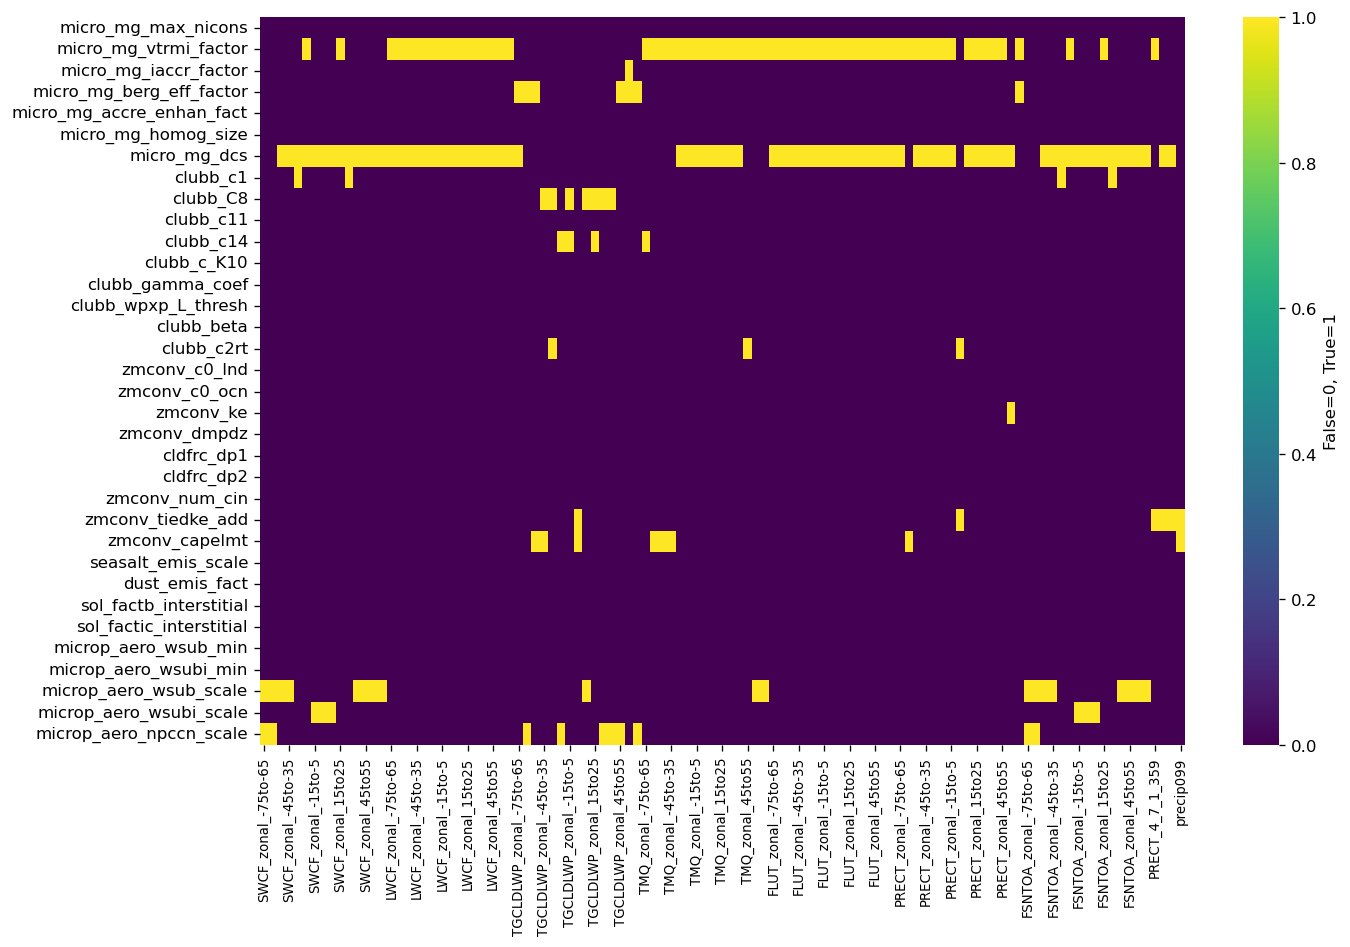

In [7]:
analysis.plot_onehot(figsize = (8, 6))

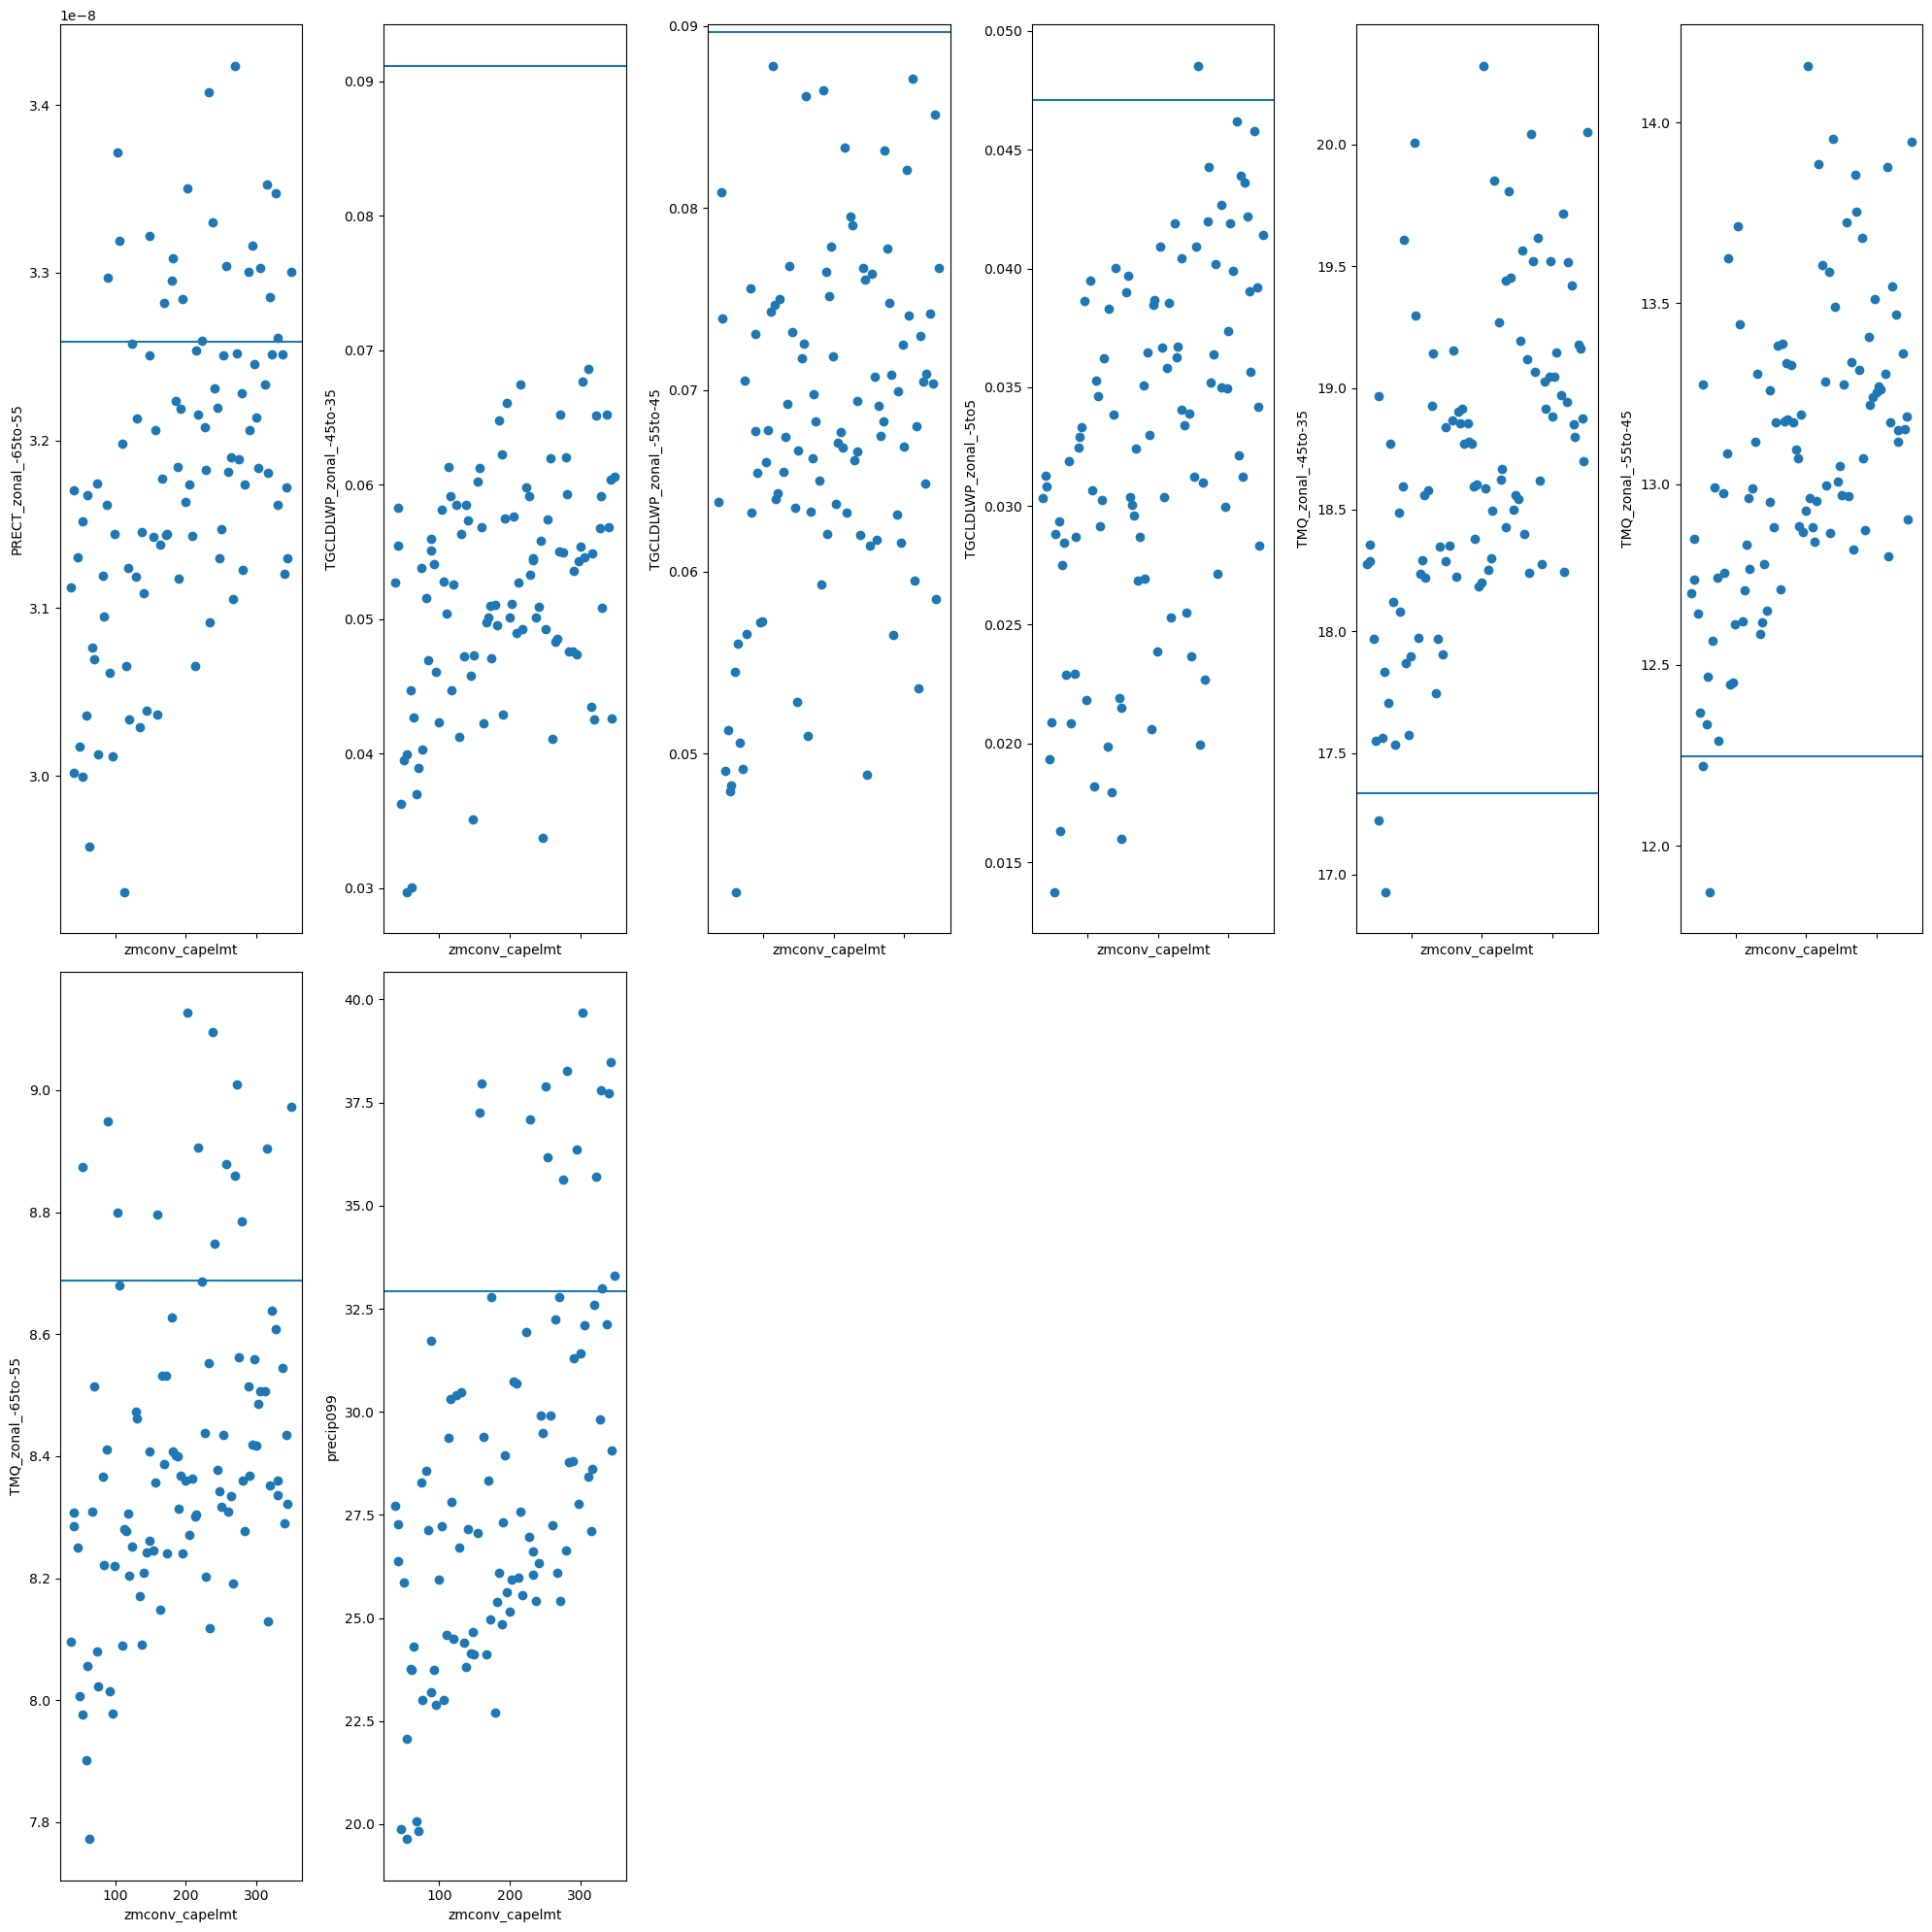

In [14]:
_ = analysis.plot_by_para('zmconv_capelmt', ncols=6, figsize = (20,20))

In [67]:
for c in list(analysis.meta_onehot.index[analysis.meta_onehot['clubb_c2rt']]):
    
    temp_out = analysis.p_emu[analysis.tf_masks[c]].clubb_c2rt.min()
    
    print(f'{c:20}: {temp_out:3.2f}')

LWCF_zonal_-25to-15 : 0.00
LWCF_zonal_-15to-5  : 0.00
LWCF_zonal_15to25   : 0.00
TGCLDLWP_zonal_5to15: 0.00
TMQ_zonal_-55to-45  : nan
TMQ_zonal_-45to-35  : nan
TMQ_zonal_-35to-25  : nan
TMQ_zonal_-25to-15  : 0.50
TMQ_zonal_-15to-5   : 0.05
TMQ_zonal_-5to5     : 0.00
TMQ_zonal_5to15     : 0.00
TMQ_zonal_15to25    : 0.00
TMQ_zonal_25to35    : 0.00
TMQ_zonal_35to45    : 0.00
TMQ_zonal_45to55    : 0.00
FLUT_zonal_-25to-15 : 0.00
FLUT_zonal_-15to-5  : 0.00
FLUT_zonal_-5to5    : 0.00
FLUT_zonal_5to15    : 0.00
FLUT_zonal_15to25   : 0.00
PRECT_zonal_-65to-55: 0.00
PRECT_zonal_-35to-25: 0.00
PRECT_zonal_-5to5   : 0.00
PRECT_zonal_5to15   : nan


In [18]:
#analysis.meta_onehot.index[analysis.meta_onehot['zmz']]


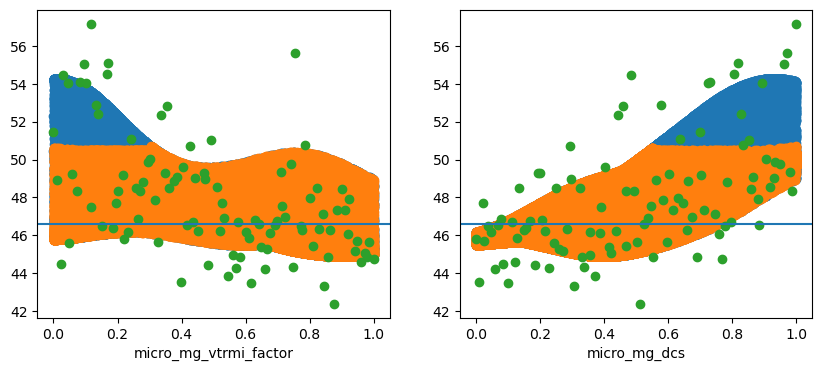

In [15]:
analysis.visualize_check('TMQ_zonal_-5to5')

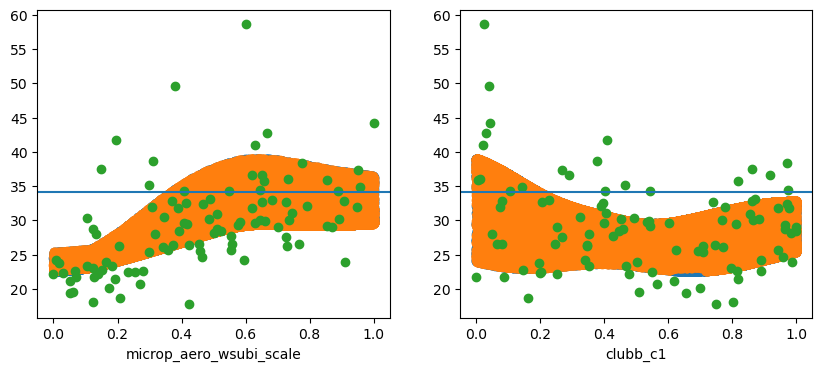

In [14]:
analysis.visualize_check('LWCF_zonal_-5to5')

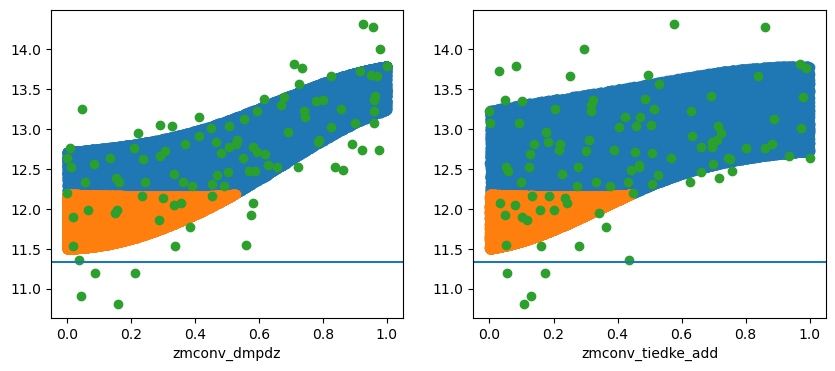

In [69]:
analysis.visualize_check('precip095')

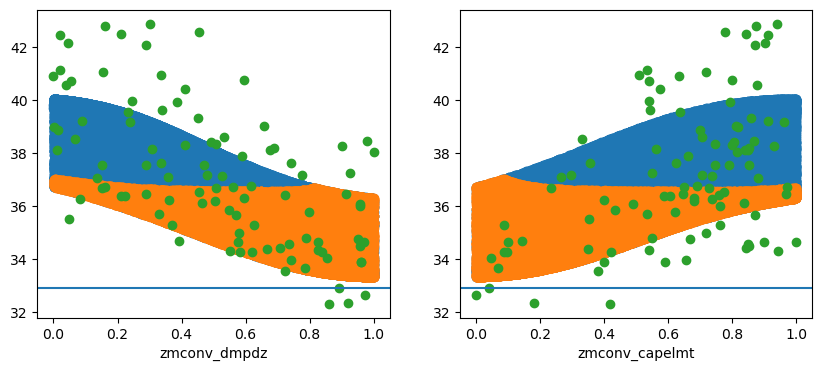

In [70]:
analysis.visualize_check('precip099')

In [10]:
analysis.data.ppe_para



,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale,hetfrz_bc_scalfac,hetfrz_dust_scalfac,micro_mg_vtrms_factor
1,1.000000e+08,1.200000,1.000000,1.000000,1.000000,0.000025,0.000500,1.000000,4.600000,0.700000,...,0.100000,0.400000,0.100000,0.001000,1.000000,1.000000,1.000000,0.010000,0.050000,1.000000
2,1.000000e+08,1.000000,1.000000,1.000000,1.000000,0.000025,0.000500,1.000000,4.500000,0.700000,...,0.100000,0.400000,0.100000,0.001000,1.000000,1.000000,1.000000,0.010000,0.050000,1.000000
3,1.000000e+08,1.366512,1.000000,1.000000,0.816432,0.000025,0.000503,1.000000,4.499788,0.700000,...,0.100000,0.400000,0.100000,0.001000,0.844572,1.458654,1.000000,0.010000,0.050000,1.000000
4,4.272341e+09,0.961199,0.903760,0.922754,1.535563,0.000072,0.000510,1.584478,4.099929,0.472819,...,0.486754,0.531962,0.306633,0.063122,0.723358,1.783946,1.071789,0.059513,0.258137,2.242130
5,2.412386e+09,1.154306,0.643733,0.912887,2.174603,0.000140,0.000540,1.019657,4.394596,0.663304,...,0.709331,0.622606,0.281124,0.035013,0.445611,1.584142,1.127913,0.026793,0.333741,1.783660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,5.504888e+09,1.379973,0.863044,0.994341,1.633984,0.000114,0.000510,1.875885,4.933708,0.409387,...,0.468806,0.417813,0.254311,0.087307,0.797482,1.005163,1.338396,0.024834,0.237751,2.186996
97,6.872362e+09,1.180784,0.616506,0.868917,1.931125,0.000027,0.000531,1.855914,4.355360,0.456915,...,0.407661,0.655377,0.121679,0.069088,0.268487,1.640843,2.445970,0.035084,0.284705,2.254403
98,3.000886e+09,1.185284,0.362943,0.997289,1.156560,0.000066,0.000537,1.868289,4.512288,0.657381,...,0.131440,0.553626,0.269295,0.088872,0.853614,1.877448,2.052206,0.033434,0.155131,1.976358
99,5.094614e+09,0.830165,0.427537,0.946186,0.906342,0.000056,0.000549,1.058901,4.677743,0.476598,...,0.679545,0.557788,0.244162,0.008912,0.738955,1.690509,1.069090,0.033031,0.087610,1.866280


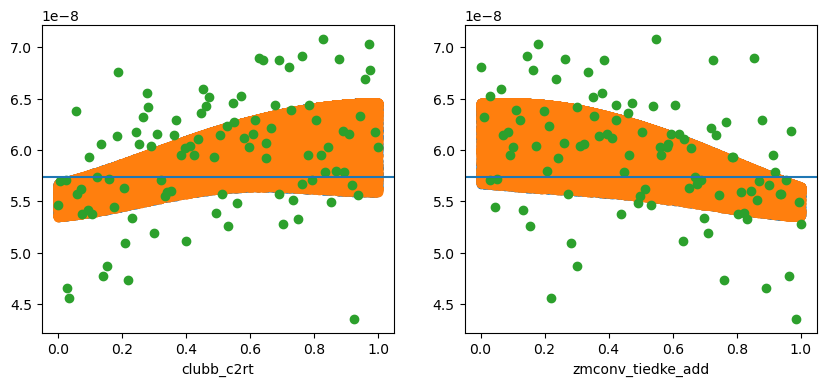

In [19]:
analysis.visualize_check('PRECT_zonal_-5to5')

In [82]:
analysis.data.pd_ppe.head(3)['SWCF_zonal_-5to5']

ppe_ind
1   -59.740660
2   -59.005750
3   -59.253113
Name: SWCF_zonal_-5to5, dtype: float64

In [84]:
analysis.data.ppe_para.head(3).T

,1,2,3
micro_mg_max_nicons,1.000000e+08,1.000000e+08,1.000000e+08
micro_mg_vtrmi_factor,1.200000e+00,1.000000e+00,1.366512e+00
micro_mg_iaccr_factor,1.000000e+00,1.000000e+00,1.000000e+00
micro_mg_berg_eff_factor,1.000000e+00,1.000000e+00,1.000000e+00
micro_mg_accre_enhan_fact,1.000000e+00,1.000000e+00,8.164318e-01
micro_mg_homog_size,2.500000e-05,2.500000e-05,2.500000e-05
micro_mg_dcs,5.000000e-04,5.000000e-04,5.030000e-04
clubb_c1,1.000000e+00,1.000000e+00,1.000000e+00
clubb_C8,4.600000e+00,4.500000e+00,4.499788e+00
clubb_c11,7.000000e-01,7.000000e-01,7.000000e-01
